# Advanced: A Simple Tropical Lapse-Rate Experiment

This notebook is a continuation of the seasonal ERA5 profile workflow, but now we simplify the problem and focus on one mechanism: how the vertical pattern of warming changes the outgoing longwave radiation. Instead of sweeping over many Arctic profiles, we start from a single tropical ERA5 profile from the ARCO archive and construct three clear-sky thermal experiments.

We do not calculate a formal feedback parameter $\lambda$ here. The goal is narrower: compare a vertically uniform warming with an upper-tropospheric amplified warming so we can see the part of the top-of-atmosphere response that points toward a lapse-rate feedback interpretation.

```{warning}
This notebook accesses ARCO ERA5 directly from Google Cloud Storage and runs a few clear-sky thermal simulations. It is much lighter than the seasonal sea-ice notebook, but it still requires network access and a working libRadtran setup.
```

In [19]:
import logging
from pathlib import Path

import gcsfs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

import pyradtran
from pyradtran import Var
from pyradtran.config import load_config

logging.getLogger("pyradtran").setLevel(logging.CRITICAL)

## Build a thermal configuration

We use the same general pyRadtran pattern as in the other advanced notebooks, but keep the experiment intentionally small: clear sky, thermal only, one profile at a time.

In [20]:
cfg_thermal = load_config()
cfg_thermal.simulation_defaults.rte_solver = "disort"
cfg_thermal.simulation_defaults.mol_abs_param = "reptran coarse"
cfg_thermal.simulation_defaults.source = "thermal"
cfg_thermal.simulation_defaults.wavelength_nm = [3000, 100000]
cfg_thermal.simulation_defaults.integrate_wavelength = True
cfg_thermal.simulation_defaults.output_columns = [
    "zout",
    "lambda",
    "sza",
    "edir",
    "eglo",
    "edn",
    "eup",
    "enet",
    "albedo",
    "heat",
]
cfg_thermal.execution.max_workers = 4
cfg_thermal.execution.cleanup_temp_files = True
cfg_thermal.execution.timeout_seconds = 3600
cfg_thermal.output.filename_prefix = "lapse_rate_feedback_thermal"

thermal_config_path = Path("config/lapse_rate_feedback_thermal.yaml")
cfg_thermal.to_yaml(thermal_config_path)

thermal_config_path

2026-04-25 14:04:03,504 - pyradtran.config - INFO - Configuration written to config/lapse_rate_feedback_thermal.yaml


PosixPath('config/lapse_rate_feedback_thermal.yaml')

## Load a tropical ERA5 profile from ARCO

To keep the case simple, we sample one tropical ocean column from ARCO ERA5. This gives us a realistic temperature and humidity structure without the full batch-processing machinery from the previous notebook.

In [21]:
gcs = gcsfs.GCSFileSystem(token="anon")
path = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"

ds_arco = xr.open_zarr(
    gcs.get_mapper(path),
    chunks="auto",
    consolidated=True,
)

target_time = "2020-07-15T12:00:00"
target_lat = 12.0
target_lon = 180.0

profile_raw = ds_arco[[
    "temperature",
    "specific_humidity",
    "geopotential",
    "sea_surface_temperature",
]].sel(
    time=target_time,
    latitude=target_lat,
    longitude=target_lon,
    method="nearest",
).load()

ds_arco.close()
profile_raw

<xarray.Dataset> Size: 760B
Dimensions:                  (level: 37)
Coordinates:
    latitude                 float32 4B 12.0
  * level                    (level) int64 296B 1 2 3 5 7 ... 925 950 975 1000
    longitude                float32 4B 180.0
    time                     datetime64[ns] 8B 2020-07-15T12:00:00
Data variables:
    temperature              (level) float32 148B 259.7 255.7 ... 297.4 299.6
    specific_humidity        (level) float32 148B 3.554e-06 ... 0.01504
    geopotential             (level) float32 148B 4.672e+05 4.159e+05 ... 878.0
    sea_surface_temperature  float32 4B 301.2
Attributes:
    last_updated:           2026-04-25 02:34:30.972015+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2025-12-31
    valid_time_stop_era5t:  2026-04-19

## Prepare warming patterns

We define two physically motivated warming perturbations that represent the canonical
lapse-rate feedback patterns for the tropics and the Arctic.

**Tropics** (λ_LR < 0 — negative feedback): convection rapidly redistributes latent heat
aloft, so the warming follows roughly the change in the moist-adiabatic lapse rate.
We approximate this with a sin-arc in log₁₀-pressure space that gives ≈ 2× surface warming
at ~300 hPa and returns to 1× at the tropopause (100 hPa).

**Arctic** (λ_LR > 0 — positive feedback): a stably stratified boundary layer prevents
turbulent mixing and traps the warming near the surface.  We approximate this with an
exponential decay whose e-folding pressure thickness is ~150 hPa, giving surface-level
warming that decays to near-zero by 700 hPa.

Specific humidity is left unchanged in both cases so the comparison isolates the
temperature-profile effect.

```{note}
For a full seasonal climatology of tropical and Arctic profiles, see
`era5_region_profiles.ipynb`.  Here we use a single ARCO ERA5 snapshot for speed.
```

In [22]:
def prepare_era5_profile(profile):
    era5_profile = profile.rename(
        {
            "temperature": "t",
            "specific_humidity": "q",
            "geopotential": "z",
            "level": "pressure_level",
            "time": "valid_time",
        }
    ).sortby("pressure_level", ascending=False)

    era5_profile["time"] = era5_profile["valid_time"]
    era5_profile["t"].attrs["units"] = "K"
    era5_profile["q"].attrs["units"] = "kg/kg"
    era5_profile["pressure_level"].attrs["units"] = "hPa"

    return era5_profile[["pressure_level", "t", "q", "z"]].load()


def tropical_lapse_pattern(pressure_hpa, delta_t_surface=2.0):
    """
    Tropical upper-tropospheric amplification following moist-adiabatic adjustment.

    Uses a sin-arc in log10-pressure space:
      amp = 1 + sin(pi * log10(1000/p))  ->  1 at 1000 hPa, 2 at ~316 hPa, 1 at 100 hPa.
    Above the tropopause (~100 hPa) warming is set to a small residual (0.3 K).

    lambda_LR < 0: more efficient OLR emission aloft -> negative feedback.
    """
    p = np.asarray(pressure_hpa, dtype=float)
    log_ratio = np.log10(1000.0 / np.maximum(p, 100.0))  # 0 at 1000 hPa, 1 at 100 hPa
    amp = 1.0 + np.sin(np.pi * log_ratio)  # arc 1 -> 2 -> 1
    return delta_t_surface * np.where(p >= 100.0, amp, 0.3)


def arctic_lapse_pattern(pressure_hpa, delta_t_surface=2.0):
    """
    Arctic near-surface amplification due to stable boundary-layer trapping.

    Exponential decay from the surface with an e-folding pressure thickness
    of ~150 hPa:
      delta_t = delta_t_surface * exp(-(1000 - p) / 150)

    At 1000 hPa: full delta_t_surface; at 850 hPa: ~37 %;
    at 700 hPa: ~14 %; at 500 hPa: ~4 %.

    lambda_LR > 0: less OLR increase (cold free troposphere barely warms)
    -> positive feedback.  BUT the warm boundary layer emits strongly
    downward, which is the key surface energy-balance signature.
    """
    p = np.asarray(pressure_hpa, dtype=float)
    return delta_t_surface * np.exp(-(1000.0 - p) / 150.0)


# ---- sanity check ----
baseline_profile = prepare_era5_profile(profile_raw)
pressure = baseline_profile["pressure_level"]

uniform_delta_t = xr.full_like(pressure, 2.0).rename("uniform_delta_t")

tropical_delta_t = xr.DataArray(
    tropical_lapse_pattern(pressure.values),
    coords=pressure.coords,
    dims=pressure.dims,
).rename("tropical_delta_t")

arctic_delta_t = xr.DataArray(
    arctic_lapse_pattern(pressure.values),
    coords=pressure.coords,
    dims=pressure.dims,
).rename("arctic_delta_t")

uniform_profile = baseline_profile.copy(deep=True)
uniform_profile["t"] = baseline_profile["t"] + uniform_delta_t

lapse_profile = baseline_profile.copy(deep=True)
lapse_profile["t"] = baseline_profile["t"] + tropical_delta_t

print("Tropical lapse warming (K) at key levels:")
for pv in [1000, 500, 316, 250, 100]:
    print(f"  {pv:5.0f} hPa: {tropical_lapse_pattern(pv):.2f} K")

print("\nArctic lapse warming (K) at key levels:")
for pv in [1000, 925, 850, 700, 500, 300]:
    print(f"  {pv:5.0f} hPa: {arctic_lapse_pattern(pv):.2f} K")

Tropical lapse warming (K) at key levels:
   1000 hPa: 2.00 K
    500 hPa: 3.62 K
    316 hPa: 4.00 K
    250 hPa: 3.90 K
    100 hPa: 2.00 K

Arctic lapse warming (K) at key levels:
   1000 hPa: 2.00 K
    925 hPa: 1.21 K
    850 hPa: 0.74 K
    700 hPa: 0.27 K
    500 hPa: 0.07 K
    300 hPa: 0.02 K


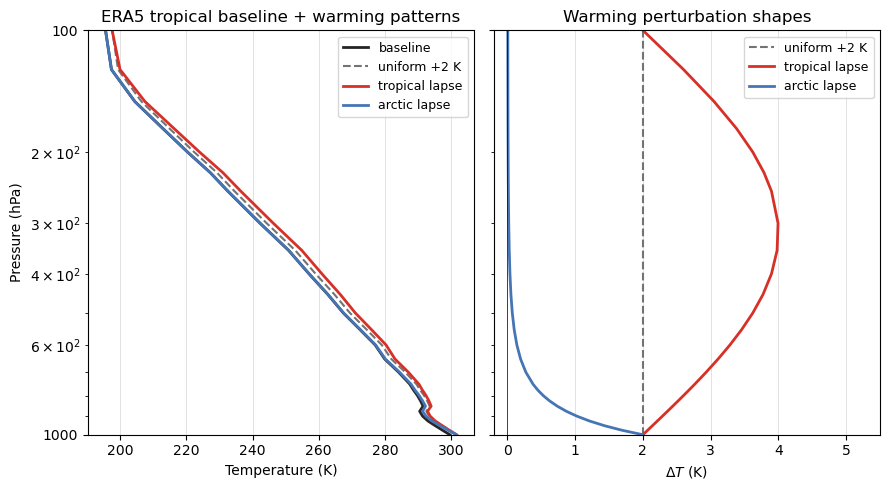

In [23]:
# Quick diagnostic: verify shape assumptions before running the simulations.
p = pressure.values

fig, axes = plt.subplots(1, 2, figsize=(9, 5), sharey=True)

C_BASE = "#252525"
C_UNI  = "#737373"
C_TR   = "#d73027"
C_ARC  = "#4575b4"

# ---- Left: T profiles (tropical baseline + both warming patterns) ----
ax = axes[0]
t0 = baseline_profile["t"].values
ax.plot(t0,                           p, color=C_BASE, lw=2.0, label="baseline")
ax.plot(t0 + 2.0,                     p, color=C_UNI,  lw=1.5, ls="--", label="uniform +2 K")
ax.plot(t0 + tropical_delta_t.values, p, color=C_TR,   lw=2.0, label="tropical lapse")
ax.plot(t0 + arctic_delta_t.values,   p, color=C_ARC,  lw=2.0, label="arctic lapse")
ax.set_yscale("log")
ax.set_ylim(1000, 100)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}"))
ax.set_xlabel("Temperature (K)")
ax.set_ylabel("Pressure (hPa)")
ax.set_title("ERA5 tropical baseline + warming patterns")
ax.legend(fontsize=9)
ax.grid(which="major", lw=0.4, color="#cccccc")

# ---- Right: ΔT shape functions ----
ax = axes[1]
ax.axvline(2, color=C_UNI, lw=1.5, ls="--", label="uniform +2 K")
ax.plot(tropical_delta_t.values, p, color=C_TR,  lw=2.0, label="tropical lapse")
ax.plot(arctic_delta_t.values,   p, color=C_ARC, lw=2.0, label="arctic lapse")
ax.set_yscale("log")
ax.set_ylim(1000, 100)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}"))
ax.set_xlabel(r"$\Delta T$ (K)")
ax.set_title("Warming perturbation shapes")
ax.set_xlim(-0.2, 5.5)
ax.axvline(0, color="k", lw=0.5)
ax.legend(fontsize=9)
ax.grid(which="major", lw=0.4, color="#cccccc")

plt.tight_layout()

## Run three clear-sky thermal simulations

The baseline case uses the original sea-surface temperature. Both warmed cases use a surface warming of 2 K, so the difference between them is entirely due to the vertical distribution of atmospheric warming.

In [24]:
def make_input_dataset(surface_temperature):
    altitudes = np.concatenate([np.arange(0, 20.5, 0.5), [25, 30, 40, 50, 70, 100]])

    return xr.Dataset(
        coords={
            "time": [pd.to_datetime(str(profile_raw["time"].values))],
            "latitude": ("time", [float(profile_raw["latitude"].values)]),
            "longitude": ("time", [float(profile_raw["longitude"].values)]),
            "altitude": ("altitude", altitudes),
        },
        data_vars={
            "albedo": ("time", [0.06]),
            "surface_temperature": ("time", [surface_temperature]),
        },
    )

baseline_surface_temperature = float(profile_raw["sea_surface_temperature"].values)
warmed_surface_temperature = baseline_surface_temperature + 2.0

experiments = {
    "baseline": {
        "input_ds": make_input_dataset(baseline_surface_temperature),
        "atmosphere": baseline_profile,
    },
    "uniform_warming": {
        "input_ds": make_input_dataset(warmed_surface_temperature),
        "atmosphere": uniform_profile,
    },
    "lapse_rate_warming": {
        "input_ds": make_input_dataset(warmed_surface_temperature),
        "atmosphere": lapse_profile,
    },
}

atm_cache_dir = cfg_thermal.paths.working_dir / "era5_atmospheres"

simulations = {}
for name, experiment in experiments.items():
    if atm_cache_dir.exists():
        for cache_file in atm_cache_dir.glob("era5_atm_*.dat"):
            cache_file.unlink()

    simulations[name] = experiment["input_ds"].pyradtran.run(
        config_path=thermal_config_path,
        params={'sur_temperature': Var('surface_temperature'), 'albedo': Var('albedo')},
        return_dataset=True,
        save_to_file=False,
        era5_atmosphere=experiment["atmosphere"],
        show_progress=False,
    )

simulations["baseline"]

<xarray.Dataset> Size: 4kB
Dimensions:   (time: 1, altitude: 47)
Coordinates:
  * time      (time) datetime64[ns] 8B 2020-07-15T12:00:00
  * altitude  (altitude) float64 376B 0.0 0.5 1.0 1.5 ... 40.0 50.0 70.0 100.0
Data variables:
    zout      (altitude, time) float64 376B 0.0 0.5 1.0 1.5 ... 50.0 70.0 100.0
    lambda    (altitude, time) float64 376B 3.001e+03 3.001e+03 ... 3.001e+03
    sza       (altitude, time) float64 376B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    edir      (altitude, time) float64 376B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    eglo      (altitude, time) float64 376B 383.1 344.6 ... 0.0004023 4.936e-06
    edn       (altitude, time) float64 376B 383.1 344.6 ... 0.0004023 4.936e-06
    eup       (altitude, time) float64 376B 459.6 437.1 420.8 ... 274.7 274.7
    enet      (altitude, time) float64 376B -76.52 -92.53 ... -274.7 -274.7
    albedo    (altitude, time) float64 376B 1.2 1.269 ... 6.826e+05 5.564e+07
    heat      (altitude, time) float64 376B -2.385 -2.85 -1.931 ... 0.0925 0.0
Attributes:
    point_id:             20200715_120000_12.00_180.00_0
    time:                 2020-07-15T12:00:00
    latitude:             12.0
    longitude:            180.0
    albedo:               0.06
    surface_temperature:  301.1914978027344
    surface_type:         None
    altitude:             None
    generated_by:         pyradtran
    pyradtran_version:    unified_system
    generation_date:      2026-04-25T14:05:22.081232

## Compare the radiative response

A useful first diagnostic is the upwelling thermal flux at the top of atmosphere. If the upper troposphere warms more than the surface, the atmosphere can emit more efficiently to space, so the longwave response differs from the vertically uniform case even though both cases use the same surface warming.

In [25]:
summary = pd.DataFrame(
    {
        "case": list(simulations.keys()),
        "surface_temperature_K": [
            float(experiments[name]["input_ds"]["surface_temperature"].values[0])
            for name in simulations
        ],
        "toa_upwelling_longwave_Wm-2": [
            float(ds_sim["eup"].isel(altitude=-1).squeeze())
            for ds_sim in simulations.values()
        ],
        "surface_net_longwave_Wm-2": [
            float(ds_sim["enet"].isel(altitude=0).squeeze())
            for ds_sim in simulations.values()
        ],
    }
).set_index("case")

summary["delta_olr_vs_baseline"] = (
    summary["toa_upwelling_longwave_Wm-2"]
    - summary.loc["baseline", "toa_upwelling_longwave_Wm-2"]
)

summary

,surface_temperature_K,toa_upwelling_longwave_Wm-2,surface_net_longwave_Wm-2,delta_olr_vs_baseline
case,,,,
baseline,301.191498,274.6530,-76.52301,0.0000
uniform_warming,303.191498,282.7966,-79.97522,8.1436
lapse_rate_warming,303.191498,285.8831,-79.67938,11.2301


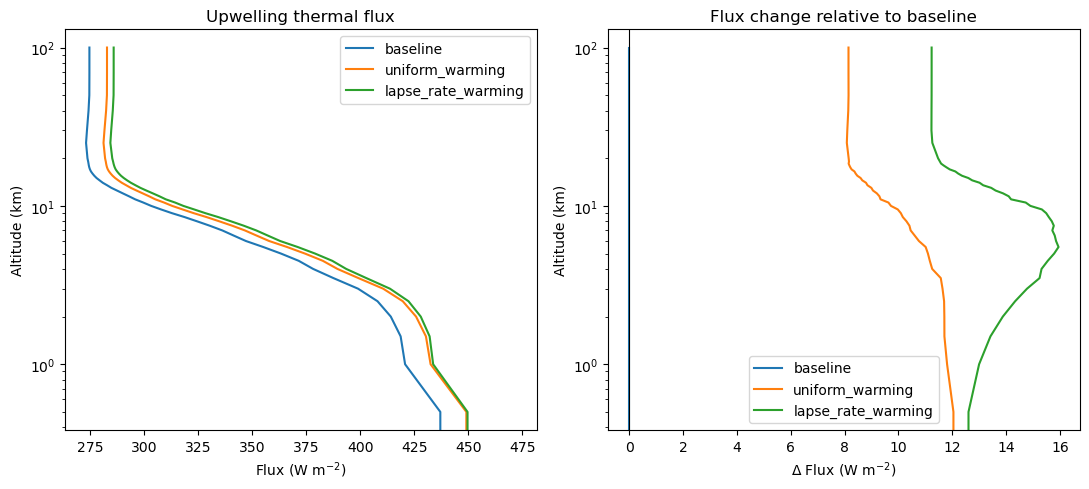

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for name, ds_sim in simulations.items():
    ds_sim["eup"].squeeze().plot(y="altitude", ax=axes[0], label=name)
    (ds_sim["eup"] - simulations["baseline"]["eup"]).squeeze().plot(
        y="altitude",
        ax=axes[1],
        label=name,
    )

axes[0].set_title("Upwelling thermal flux")
axes[0].set_xlabel(r"Flux (W m$^{-2}$)")
axes[0].set_ylabel("Altitude (km)")
axes[0].legend()
axes[0].set_yscale("log")


axes[1].set_title("Flux change relative to baseline")
axes[1].set_xlabel(r"$\Delta$ Flux (W m$^{-2}$)")
axes[1].set_ylabel("Altitude (km)")
axes[1].axvline(0, color="k", linewidth=0.8)
axes[1].legend()
axes[1].set_yscale("log")

plt.tight_layout()

The quantity to watch is the difference between `uniform_warming` and `lapse_rate_warming` at the top of atmosphere. Both experiments warm the surface by the same amount, so that gap is the piece coming from the vertical structure of atmospheric warming rather than the imposed surface change itself.

That is not yet a full feedback calculation, but it is the core radiative idea behind a lapse-rate feedback: where the warming occurs matters for how efficiently the column emits longwave radiation back to space.

## Toward a simple $\lambda$-style normalization

A next step toward feedback language is to normalize flux changes by imposed surface warming. Here we keep it simple and diagnostic:

- TOA longwave sensitivity: $\Delta \mathrm{OLR} / \Delta T_s$
- Surface longwave sensitivity: $\Delta \mathrm{net\ LW}_{\mathrm{surface}} / \Delta T_s$

This is still not a full climate feedback decomposition, but it puts the experiment on a per-kelvin basis.

In [27]:
summary_lambda = summary.copy()
summary_lambda["delta_surface_temp_K"] = (
    summary_lambda["surface_temperature_K"] - summary_lambda.loc["baseline", "surface_temperature_K"]
)

for column in ["toa_upwelling_longwave_Wm-2", "surface_net_longwave_Wm-2"]:
    delta_name = f"delta_{column}"
    sens_name = f"sensitivity_{column}_perK"
    summary_lambda[delta_name] = summary_lambda[column] - summary_lambda.loc["baseline", column]
    summary_lambda[sens_name] = summary_lambda[delta_name] / summary_lambda["delta_surface_temp_K"]

summary_lambda

,surface_temperature_K,toa_upwelling_longwave_Wm-2,surface_net_longwave_Wm-2,delta_olr_vs_baseline,delta_surface_temp_K,delta_toa_upwelling_longwave_Wm-2,sensitivity_toa_upwelling_longwave_Wm-2_perK,delta_surface_net_longwave_Wm-2,sensitivity_surface_net_longwave_Wm-2_perK
case,,,,,,,,,
baseline,301.191498,274.6530,-76.52301,0.0000,0.0,0.0000,NaN,0.00000,NaN
uniform_warming,303.191498,282.7966,-79.97522,8.1436,2.0,8.1436,4.07180,-3.45221,-1.726105
lapse_rate_warming,303.191498,285.8831,-79.67938,11.2301,2.0,11.2301,5.61505,-3.15637,-1.578185


### Short Side Note: TOA vs Surface Perspective

For tropical lapse-rate interpretation, TOA longwave response is a clean first diagnostic because it tracks how efficiently the atmospheric column emits to space. In the Arctic, the surface energy budget is often the more decision-relevant view: small changes in downwelling and upwelling longwave at the surface directly affect sea ice, ocean-atmosphere coupling, and near-surface temperature evolution.

So in the next section we compare both metrics, but we emphasize surface-net longwave differences for the Arctic case.

## Arctic vs Tropics: same framework, different perspective

Now we construct one Arctic profile and one tropical profile, then run three clear-sky thermal cases per region: baseline, uniform +2 K warming, and a region-shaped warming profile.

- Tropics: upper-tropospheric amplified warming (reduced lapse-rate style)
- Arctic: near-surface amplified warming (boundary-layer focused)

We report both TOA and surface sensitivities, with extra attention to surface-net longwave in the Arctic.

In [31]:
def make_input_dataset_for_profile(profile_point, surface_temperature):
    altitudes = np.concatenate([np.arange(0, 20.5, 0.5), [25, 30, 40, 50, 70, 100]])
    valid_time = pd.to_datetime(str(profile_point["time"].values))
    lat_val = float(profile_point["latitude"].values) if "latitude" in profile_point.coords else float(profile_point.attrs.get("representative_lat", 0.0))
    lon_val = float(profile_point["longitude"].values) if "longitude" in profile_point.coords else float(profile_point.attrs.get("representative_lon", 0.0))

    return xr.Dataset(
        coords={
            "time": [valid_time],
            "latitude": ("time", [lat_val]),
            "longitude": ("time", [lon_val]),
            "altitude": ("altitude", altitudes),
        },
        data_vars={
            "albedo": ("time", [0.06]),
            "surface_temperature": ("time", [surface_temperature]),
        },
    )


def build_region_warming(pressure, region):
    """Return (uniform_delta_t, lapse_delta_t) xarray DataArrays for the given region.

    Uses the physically motivated functions defined in the setup cell:
    - tropical_lapse_pattern: sin-arc amplification peaking at ~316 hPa
    - arctic_lapse_pattern: exponential decay from surface (e-folding ~150 hPa)
    """
    uniform = xr.full_like(pressure, 2.0).rename("uniform_delta_t")

    if region == "tropics":
        shaped_vals = tropical_lapse_pattern(pressure.values)
    elif region == "arctic":
        shaped_vals = arctic_lapse_pattern(pressure.values)
    else:
        raise ValueError(f"Unknown region: {region}")

    shaped = xr.DataArray(
        shaped_vals,
        coords=pressure.coords,
        dims=pressure.dims,
    ).rename("shaped_delta_t")

    return uniform, shaped


def run_region_experiment(profile_point, region_name):
    baseline = prepare_era5_profile(profile_point)
    pressure = baseline["pressure_level"]

    uniform_delta, shaped_delta = build_region_warming(pressure, region_name)

    uniform_profile_local = baseline.copy(deep=True)
    uniform_profile_local["t"] = baseline["t"] + uniform_delta

    shaped_profile_local = baseline.copy(deep=True)
    shaped_profile_local["t"] = baseline["t"] + shaped_delta

    sst_baseline = float(profile_point["sea_surface_temperature"].values)
    sst_warmed   = sst_baseline + 2.0

    cases = {
        "baseline": {
            "input_ds": make_input_dataset_for_profile(profile_point, sst_baseline),
            "atmosphere": baseline,
        },
        "uniform_warming": {
            "input_ds": make_input_dataset_for_profile(profile_point, sst_warmed),
            "atmosphere": uniform_profile_local,
        },
        "lapse_pattern_warming": {
            "input_ds": make_input_dataset_for_profile(profile_point, sst_warmed),
            "atmosphere": shaped_profile_local,
        },
    }

    local_sims = {}
    for case_name, case in cases.items():
        if atm_cache_dir.exists():
            for cache_file in atm_cache_dir.glob("era5_atm_*.dat"):
                cache_file.unlink()

        local_sims[case_name] = case["input_ds"].pyradtran.run(
            config_path=thermal_config_path,
            params={'sur_temperature': Var('surface_temperature'), 'albedo': Var('albedo')},
            return_dataset=True,
            save_to_file=False,
            era5_atmosphere=case["atmosphere"],
            show_progress=False,
        )

    table = pd.DataFrame(
        {
            "case": list(local_sims.keys()),
            "surface_temperature_K": [
                float(cases[name]["input_ds"]["surface_temperature"].values[0])
                for name in local_sims
            ],
            "toa_upwelling_longwave_Wm-2": [
                float(ds_sim["eup"].isel(altitude=-1).squeeze())
                for ds_sim in local_sims.values()
            ],
            "surface_net_longwave_Wm-2": [
                float(ds_sim["enet"].isel(altitude=0).squeeze())
                for ds_sim in local_sims.values()
            ],
            "surface_downwelling_lw_Wm-2": [
                float(ds_sim["edn"].isel(altitude=0).squeeze())
                for ds_sim in local_sims.values()
            ],
        }
    ).set_index("case")

    table["delta_surface_temp_K"] = (
        table["surface_temperature_K"] - table.loc["baseline", "surface_temperature_K"]
    )
    table["dtoa"]   = table["toa_upwelling_longwave_Wm-2"]   - table.loc["baseline", "toa_upwelling_longwave_Wm-2"]
    table["dseblw"] = table["surface_net_longwave_Wm-2"]     - table.loc["baseline", "surface_net_longwave_Wm-2"]
    table["ddnlw"]  = table["surface_downwelling_lw_Wm-2"]   - table.loc["baseline", "surface_downwelling_lw_Wm-2"]
    table["lambda_toa_perK"]     = table["dtoa"]   / table["delta_surface_temp_K"]
    table["lambda_surface_perK"] = table["dseblw"] / table["delta_surface_temp_K"]
    table["lambda_dndlw_perK"]   = table["ddnlw"]  / table["delta_surface_temp_K"]
    table["region"] = region_name

    return table, local_sims


# ------------------------------------------------------------------
# Load profiles: prefer processed climatology, fall back to ARCO snapshot
# ------------------------------------------------------------------
processed_path = Path("data/era5_region_profiles.nc")
common_time    = "2020-07-15T12:00:00"   # used as synthetic time stamp for climatological profiles

if processed_path.exists():
    print("Loading from processed climatology…")
    ds_region = xr.open_dataset(processed_path)
    # Use JJA for Arctic summer (most relevant season for sea ice)
    profile_tropics = (
        ds_region.sel(region="tropics", season="JJA")
        .rename({"t": "temperature", "q": "specific_humidity",
                 "z": "geopotential", "pressure_level": "level"})
        .assign_coords(
            time=pd.to_datetime(common_time),
            latitude=12.0,   # representative tropical ocean point
            longitude=180.0,
        )
    )
    profile_arctic = (
        ds_region.sel(region="arctic", season="JJA")
        .rename({"t": "temperature", "q": "specific_humidity",
                 "z": "geopotential", "pressure_level": "level"})
        .assign_coords(
            time=pd.to_datetime(common_time),
            latitude=80.0,   # representative Arctic Ocean point
            longitude=0.0,
        )
    )
    # synthetic SST: near-surface temperature from the mean profile
    profile_tropics["sea_surface_temperature"] = float(
        profile_tropics["temperature"].sel(level=1000.0, method="nearest").values
    )
    profile_arctic["sea_surface_temperature"] = float(
        profile_arctic["temperature"].sel(level=1000.0, method="nearest").values
    )
else:
    print("Processed file not found – fetching single ARCO snapshots (run era5_region_profiles.ipynb first for better results).")
    gcs_compare  = gcsfs.GCSFileSystem(token="anon")
    arco_path    = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"
    ds_arco_compare = xr.open_zarr(
        gcs_compare.get_mapper(arco_path), chunks="auto", consolidated=True
    )
    _vars = ["temperature", "specific_humidity", "geopotential", "sea_surface_temperature"]
    profile_tropics = ds_arco_compare[_vars].sel(
        time=common_time, latitude=12.0, longitude=180.0, method="nearest"
    ).load()
    profile_arctic = ds_arco_compare[_vars].sel(
        time=common_time, latitude=80.0, longitude=0.0, method="nearest"
    ).load()
    ds_arco_compare.close()


table_tropics, sims_tropics = run_region_experiment(profile_tropics, "tropics")
table_arctic,  sims_arctic  = run_region_experiment(profile_arctic,  "arctic")

regional_summary = pd.concat([table_tropics, table_arctic])
regional_summary


Loading from processed climatology…


,surface_temperature_K,toa_upwelling_longwave_Wm-2,surface_net_longwave_Wm-2,surface_downwelling_lw_Wm-2,delta_surface_temp_K,dtoa,dseblw,ddnlw,lambda_toa_perK,lambda_surface_perK,lambda_dndlw_perK,region
case,,,,,,,,,,,,
baseline,298.477875,275.9196,-60.42618,383.6239,0.0,0.0000,0.00000,0.0000,NaN,NaN,NaN,tropics
uniform_warming,300.477875,283.7797,-63.53494,392.4820,2.0,7.8601,-3.10876,8.8581,3.93005,-1.554380,4.42905,tropics
lapse_pattern_warming,300.477875,287.2274,-63.20831,392.8294,2.0,11.3078,-2.78213,9.2055,5.65390,-1.391065,4.60275,tropics
baseline,275.858887,234.8417,-77.52226,243.9498,0.0,0.0000,0.00000,0.0000,NaN,NaN,NaN,arctic
uniform_warming,277.858887,241.8163,-80.42809,250.4690,2.0,6.9746,-2.90583,6.5192,3.48730,-1.452915,3.25960,arctic
lapse_pattern_warming,277.858887,238.0214,-81.52103,249.3063,2.0,3.1797,-3.99877,5.3565,1.58985,-1.999385,2.67825,arctic


Saved to ../../output/lapse_rate_feedback_fig.pdf


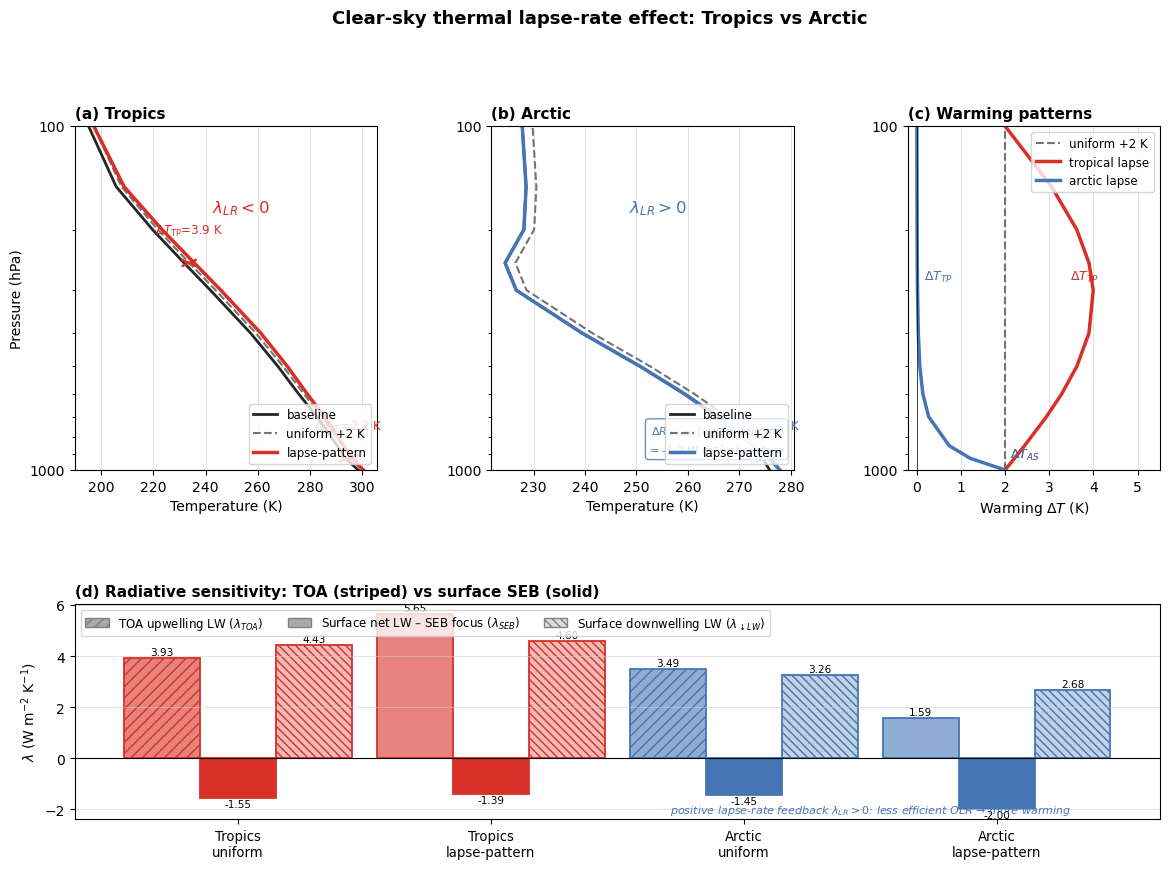

In [33]:
import matplotlib.gridspec as mgridspec
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from pathlib import Path as _P

C_BASE = "#252525"
C_UNI  = "#737373"
C_TR   = "#d73027"   # red  – tropics
C_ARC  = "#4575b4"   # blue – arctic

PMIN, PMAX = 100, 1000


def _setup_profile_ax(ax, title):
    ax.set_yscale("log")
    ax.set_ylim(PMAX, PMIN)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v)}"))
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.set_xlabel("Temperature (K)", fontsize=10)
    ax.set_ylabel("Pressure (hPa)", fontsize=10)
    ax.set_title(title, loc="left", fontweight="bold", fontsize=11)
    ax.grid(which="major", lw=0.4, color="#cccccc", zorder=0)


def _arrow(ax, p_val, p_arr, t_a, t_b, color, label):
    """Double-headed annotation arrow at pressure p_val between t_a and t_b."""
    idx = int(np.argmin(np.abs(p_arr - p_val)))
    ta, tb = t_a[idx], t_b[idx]
    if abs(tb - ta) < 0.05:
        return
    ax.annotate(
        "",
        xy=(tb, p_arr[idx]),
        xytext=(ta, p_arr[idx]),
        arrowprops=dict(arrowstyle="<->", color=color, lw=1.8, mutation_scale=11),
    )
    ax.text(
        (ta + tb) / 2,
        p_arr[idx] / 1.18,   # just above the arrow in log space
        f"$\\Delta T_{{\\mathrm{{{label}}}}}$={abs(tb - ta):.1f} K",
        ha="center", va="bottom", fontsize=8.5, color=color,
    )


# ============================================================
# Build actual profiles with revised warming patterns
# ============================================================
trp_base = prepare_era5_profile(profile_tropics)
arc_base = prepare_era5_profile(profile_arctic)
p = trp_base["pressure_level"].values   # same levels for both

t_trp_base = trp_base["t"].values
t_arc_base = arc_base["t"].values

t_trp_uni  = t_trp_base + 2.0
t_arc_uni  = t_arc_base + 2.0

t_trp_laps = t_trp_base + tropical_lapse_pattern(p)
t_arc_laps = t_arc_base + arctic_lapse_pattern(p)

# ============================================================
# Figure layout
# ============================================================
fig = plt.figure(figsize=(14, 9))
gs = mgridspec.GridSpec(
    2, 3,
    figure=fig,
    width_ratios=[2.4, 2.4, 2.0],
    height_ratios=[4.0, 2.5],
    hspace=0.48, wspace=0.40,
)

ax_trp = fig.add_subplot(gs[0, 0])
ax_arc = fig.add_subplot(gs[0, 1], sharey=ax_trp)
ax_dt  = fig.add_subplot(gs[0, 2], sharey=ax_trp)
ax_lam = fig.add_subplot(gs[1, :])

# ============================================================
# Panel (a): Tropics T(p)
# ============================================================
_setup_profile_ax(ax_trp, "(a) Tropics")
ax_trp.plot(t_trp_base, p, color=C_BASE, lw=2.0, label="baseline")
ax_trp.plot(t_trp_uni,  p, color=C_UNI,  lw=1.5, ls="--", label="uniform +2 K")
ax_trp.plot(t_trp_laps, p, color=C_TR,   lw=2.5, label="lapse-pattern")
# Annotate ΔT_TP and ΔT_AS vs baseline
_arrow(ax_trp, 250, p, t_trp_base, t_trp_laps, C_TR, "TP")
_arrow(ax_trp, 950, p, t_trp_base, t_trp_laps, C_TR, "AS")
ax_trp.text(0.55, 0.75, r"$\lambda_{LR} < 0$",
            transform=ax_trp.transAxes, ha="center", fontsize=12,
            color=C_TR, fontweight="bold")
ax_trp.legend(fontsize=8.5, loc="lower right")

# ============================================================
# Panel (b): Arctic T(p)
# ============================================================
_setup_profile_ax(ax_arc, "(b) Arctic")
ax_arc.set_ylabel("")   # shared y-axis
ax_arc.plot(t_arc_base, p, color=C_BASE, lw=2.0, label="baseline")
ax_arc.plot(t_arc_uni,  p, color=C_UNI,  lw=1.5, ls="--", label="uniform +2 K")
ax_arc.plot(t_arc_laps, p, color=C_ARC,  lw=2.5, label="lapse-pattern")
_arrow(ax_arc, 250, p, t_arc_base, t_arc_laps, C_ARC, "TP")
_arrow(ax_arc, 950, p, t_arc_base, t_arc_laps, C_ARC, "AS")
ax_arc.text(0.55, 0.75, r"$\lambda_{LR} > 0$",
            transform=ax_arc.transAxes, ha="center", fontsize=12,
            color=C_ARC, fontweight="bold")

# Arctic SEB highlight: extra downwelling LW vs uniform
ddnlw_arc = (
    table_arctic.loc["lapse_pattern_warming", "ddnlw"]
    - table_arctic.loc["uniform_warming", "ddnlw"]
)
ax_arc.text(
    0.97, 0.04,
    f"$\\Delta R_{{\\downarrow,\\,LW}}$ (lapse\u2013uniform)\n= {ddnlw_arc:+.1f} W m$^{{-2}}$ at surface",
    transform=ax_arc.transAxes, ha="right", va="bottom", fontsize=8.0,
    color=C_ARC, style="italic",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor=C_ARC),
)
ax_arc.legend(fontsize=8.5, loc="lower right")

# ============================================================
# Panel (c): ΔT shape comparison
# ============================================================
ax_dt.set_yscale("log")
ax_dt.set_ylim(PMAX, PMIN)
ax_dt.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v)}"))
ax_dt.yaxis.set_minor_formatter(mticker.NullFormatter())
ax_dt.set_ylabel("")   # shared
ax_dt.set_xlabel(r"Warming $\Delta T$ (K)", fontsize=10)
ax_dt.set_title("(c) Warming patterns", loc="left", fontweight="bold", fontsize=11)
ax_dt.grid(which="major", lw=0.4, color="#cccccc", zorder=0)
ax_dt.axvline(2, color=C_UNI, lw=1.5, ls="--", label="uniform +2 K")
ax_dt.plot(tropical_lapse_pattern(p), p, color=C_TR,  lw=2.5, label="tropical lapse")
ax_dt.plot(arctic_lapse_pattern(p),   p, color=C_ARC, lw=2.5, label="arctic lapse")
ax_dt.axvline(0, color="k", lw=0.5)
ax_dt.set_xlim(-0.2, 5.5)
ax_dt.legend(fontsize=8.5)
ax_dt.text(3.8, 280, r"$\Delta T_{TP}$", color=C_TR,  fontsize=9, ha="center")
ax_dt.text(0.5, 280, r"$\Delta T_{TP}$", color=C_ARC, fontsize=9, ha="center")
ax_dt.text(2.1, 920, r"$\Delta T_{AS}$", color=C_TR,  fontsize=9, ha="left")
ax_dt.text(2.1, 920, r"$\Delta T_{AS}$", color=C_ARC, fontsize=9, ha="left")

# ============================================================
# Panel (d): Radiative sensitivities
# ============================================================
ax_lam.set_title(
    "(d) Radiative sensitivity: TOA (striped) vs surface SEB (solid)",
    loc="left", fontweight="bold", fontsize=11,
)
ax_lam.set_ylabel(r"$\lambda$ (W m$^{-2}$ K$^{-1}$)", fontsize=10)
ax_lam.grid(axis="y", lw=0.4, color="#cccccc", zorder=0)

cases_plot = [
    ("Tropics\nuniform",       "tropics", "uniform_warming",       C_TR,  "///"),
    ("Tropics\nlapse-pattern", "tropics", "lapse_pattern_warming",  C_TR,  ""),
    ("Arctic\nuniform",        "arctic",  "uniform_warming",        C_ARC, "///"),
    ("Arctic\nlapse-pattern",  "arctic",  "lapse_pattern_warming",  C_ARC, ""),
]

x = np.arange(len(cases_plot))
bw = 0.30
toa_vals, seb_vals, dn_vals = [], [], []
colors, hatches, labels = [], [], []

for lbl, region, case, color, hatch in cases_plot:
    tab = table_tropics if region == "tropics" else table_arctic
    toa_vals.append(tab.loc[case, "lambda_toa_perK"] if case in tab.index else 0.0)
    seb_vals.append(tab.loc[case, "lambda_surface_perK"] if case in tab.index else 0.0)
    dn_vals.append(tab.loc[case, "lambda_dndlw_perK"] if case in tab.index else 0.0)
    colors.append(color)
    hatches.append(hatch)
    labels.append(lbl)

bars_toa = ax_lam.bar(
    x - bw, toa_vals, bw,
    color=[c + "99" for c in colors], hatch=hatches,
    edgecolor=colors, linewidth=1.3,
)
bars_seb = ax_lam.bar(
    x,      seb_vals, bw,
    color=colors, edgecolor=colors, linewidth=1.3,
)
bars_dn  = ax_lam.bar(
    x + bw, dn_vals,  bw,
    color=[c + "55" for c in colors], edgecolor=colors, linewidth=1.3,
    hatch="\\\\\\\\"
)

for bars in (bars_toa, bars_seb, bars_dn):
    for bar in bars:
        h = bar.get_height()
        sign = 1 if h >= 0 else -1
        ax_lam.text(
            bar.get_x() + bar.get_width() / 2,
            h + sign * 0.04,
            f"{h:.2f}",
            ha="center",
            va="bottom" if h >= 0 else "top",
            fontsize=7.5,
        )

ax_lam.set_xticks(x)
ax_lam.set_xticklabels(labels, fontsize=9.5)
ax_lam.axhline(0, color="k", lw=0.8)

legend_handles = [
    mpatches.Patch(facecolor="#aaaaaa", hatch="///", edgecolor="gray",  label=r"TOA upwelling LW ($\lambda_{TOA}$)"),
    mpatches.Patch(facecolor="#aaaaaa",              edgecolor="gray",  label=r"Surface net LW – SEB focus ($\lambda_{SEB}$)"),
    mpatches.Patch(facecolor="#dddddd", hatch="\\\\\\\\", edgecolor="gray", label=r"Surface downwelling LW ($\lambda_{\downarrow LW}$)"),
]
ax_lam.legend(handles=legend_handles, fontsize=8.5, loc="upper left", ncol=3)

# Annotate sign interpretation
ax_lam.annotate(
    r"positive lapse-rate feedback $\lambda_{LR}>0$: less efficient OLR → more warming",
    xy=(2.5, min(seb_vals) - 0.15), fontsize=8, color=C_ARC,
    ha="center", style="italic",
)

fig.suptitle(
    "Clear-sky thermal lapse-rate effect: Tropics vs Arctic",
    fontsize=13, fontweight="bold", y=1.01,
)

out_path = _P("../../output/lapse_rate_feedback_fig.pdf")
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, bbox_inches="tight", dpi=150)
print(f"Saved to {out_path}")
plt.show()

In this simple setup, both regions can show a clear TOA signal, but the interpretation priority differs.

For the tropics, the TOA-per-kelvin contrast between uniform and lapse-shaped warming is a direct way to diagnose lapse-rate behavior. For the Arctic, the surface-per-kelvin contrast is often more actionable, because it maps more directly onto local surface warming and sea-ice relevant energetics.

So a practical workflow is: use TOA metrics to understand radiative mechanism, then use surface energy budget metrics to understand Arctic impact.

## Radiative kernels and formal feedback decomposition

The experiments we have already run give us everything needed to compute proper
radiative kernels and decompose the TOA longwave response into the standard
**Planck** and **lapse-rate** feedbacks (Soden & Held 2006; Shell et al. 2008).

### Definitions

The total radiative response at TOA to a surface warming $\Delta T_s$ is

$$
\Delta R = \frac{\partial R}{\partial T_s} \Delta T_s
         + \int_p \frac{\partial R}{\partial T(p)} \Delta T(p) \,\frac{dp}{g}
$$

We split this into two kernels:

| Kernel | Forcing | Physical meaning |
|---|---|---|
| $K_{T_s}$ | +1 K at surface only | Planck response of the surface |
| $K_{T_a}(p)$ | +1 K at level $p$, surface unchanged | Planck response of the atmosphere |

From those we get the standard feedbacks (W m⁻² K⁻¹):

$$
\lambda_{\mathrm{Planck}} = K_{T_s} + \int_p K_{T_a}(p)\,\frac{dp}{g}
\quad \text{(uniform 1 K column warming)}
$$

$$
\lambda_{\mathrm{LR}} = \int_p K_{T_a}(p)\,\bigl[\alpha(p) - 1\bigr]\,\frac{dp}{g}
\quad \text{(deviation of the actual warming shape } \alpha(p) \text{ from uniform)}
$$

where $\alpha(p) = \Delta T(p) / \Delta T_s$ is the **normalised warming profile**.

The **total** feedback is then $\lambda = \lambda_{\mathrm{Planck}} + \lambda_{\mathrm{LR}}$.


In [34]:
# =============================================================
# Step 1 – build finite-difference radiative kernels via pyRadtran
# =============================================================
# We perturb:
#   (a) surface temperature +1 K, atmosphere unchanged  -> K_Ts
#   (b) one pressure level at a time +1 K, surface unchanged -> K_Ta(p)
#
# All runs reuse the existing thermal config and the climatological
# profiles already loaded (trp_base / arc_base from Cell 22).
# =============================================================

DELTA_T_KERNEL = 1.0          # finite-difference step (K)
KERNEL_LEVELS  = [1000, 925, 850, 700, 600, 500, 400, 300, 250, 200, 150, 100]  # hPa


def _run_single(profile, profile_point, extra_tag=""):
    """Run one clear-sky thermal simulation; return the Dataset."""
    if atm_cache_dir.exists():
        for f in atm_cache_dir.glob("era5_atm_*.dat"):
            f.unlink()

    # Shift time slightly so each run gets a unique cache key
    import hashlib
    tag = hashlib.md5(extra_tag.encode()).hexdigest()[:6]
    # We exploit the latitude offset trick: nudge lat by a tiny unique amount
    # so pyRadtran doesn't reuse a stale cached atmosphere file.
    lat_offset = int(tag, 16) * 1e-6   # sub-microdegree, physically irrelevant

    lat_base = float(profile_point["latitude"].values) if "latitude" in profile_point.coords else 0.0
    lon_base = float(profile_point["longitude"].values) if "longitude" in profile_point.coords else 0.0

    altitudes = np.concatenate([np.arange(0, 20.5, 0.5), [25, 30, 40, 50, 70, 100]])
    valid_time = pd.to_datetime(str(profile_point["time"].values))
    sst = float(profile_point["sea_surface_temperature"].values)

    input_ds = xr.Dataset(
        coords={
            "time": [valid_time],
            "latitude":  ("time", [lat_base + lat_offset]),
            "longitude": ("time", [lon_base]),
            "altitude":  ("altitude", altitudes),
        },
        data_vars={
            "albedo":              ("time", [0.06]),
            "surface_temperature": ("time", [sst]),
        },
    )

    return input_ds.pyradtran.run(
        config_path=thermal_config_path,
        params={'sur_temperature': Var('surface_temperature'), 'albedo': Var('albedo')},
        return_dataset=True,
        save_to_file=False,
        era5_atmosphere=profile,
        show_progress=False,
    )


def compute_kernels(base_profile, base_profile_point, region_label):
    """
    Compute K_Ts and K_Ta(p) for the given ERA5 profile.

    Returns
    -------
    k_ts   : float  – TOA OLR change per K surface warming (W m⁻² K⁻¹)
    k_ta   : dict   – {pressure_hPa: TOA OLR change per K atmospheric warming}
    ds_ref : Dataset – reference (unperturbed) simulation
    """
    print(f"\n[{region_label}] Reference run …")
    ds_ref = _run_single(base_profile, base_profile_point, f"{region_label}_ref")
    olr_ref = float(ds_ref["eup"].isel(altitude=-1).squeeze())

    # ---- K_Ts: surface +1 K only -----------------------------------
    print(f"[{region_label}] K_Ts …")
    # Build a profile with unchanged atmosphere but sst+1 K
    lat_base = float(base_profile_point["latitude"].values) if "latitude" in base_profile_point.coords else 0.0
    lon_base = float(base_profile_point["longitude"].values) if "longitude" in base_profile_point.coords else 0.0
    altitudes = np.concatenate([np.arange(0, 20.5, 0.5), [25, 30, 40, 50, 70, 100]])
    valid_time = pd.to_datetime(str(base_profile_point["time"].values))
    sst = float(base_profile_point["sea_surface_temperature"].values)

    import hashlib
    tag = hashlib.md5(f"{region_label}_kts".encode()).hexdigest()[:6]
    lat_off = int(tag, 16) * 1e-6

    if atm_cache_dir.exists():
        for f in atm_cache_dir.glob("era5_atm_*.dat"):
            f.unlink()

    input_kts = xr.Dataset(
        coords={
            "time": [valid_time],
            "latitude":  ("time", [lat_base + lat_off]),
            "longitude": ("time", [lon_base]),
            "altitude":  ("altitude", altitudes),
        },
        data_vars={
            "albedo":              ("time", [0.06]),
            "surface_temperature": ("time", [sst + DELTA_T_KERNEL]),
        },
    )
    ds_kts = input_kts.pyradtran.run(
        config_path=thermal_config_path,
        params={'sur_temperature': Var('surface_temperature'), 'albedo': Var('albedo')},
        return_dataset=True,
        save_to_file=False,
        era5_atmosphere=base_profile,   # atmosphere UNCHANGED
        show_progress=False,
    )
    k_ts = (float(ds_kts["eup"].isel(altitude=-1).squeeze()) - olr_ref) / DELTA_T_KERNEL

    # ---- K_Ta(p): one level at a time +1 K -------------------------
    k_ta = {}
    pressure_vals = base_profile["pressure_level"].values
    for plev in KERNEL_LEVELS:
        # find nearest level in the profile
        idx_p = int(np.argmin(np.abs(pressure_vals - plev)))
        actual_p = float(pressure_vals[idx_p])
        print(f"[{region_label}] K_Ta  {actual_p:.0f} hPa …", end=" ", flush=True)

        pert_profile = base_profile.copy(deep=True)
        pert_profile["t"].values[idx_p] += DELTA_T_KERNEL

        tag2 = hashlib.md5(f"{region_label}_kta_{plev}".encode()).hexdigest()[:6]
        lat_off2 = int(tag2, 16) * 1e-6

        if atm_cache_dir.exists():
            for f in atm_cache_dir.glob("era5_atm_*.dat"):
                f.unlink()

        input_kta = xr.Dataset(
            coords={
                "time": [valid_time],
                "latitude":  ("time", [lat_base + lat_off2]),
                "longitude": ("time", [lon_base]),
                "altitude":  ("altitude", altitudes),
            },
            data_vars={
                "albedo":              ("time", [0.06]),
                "surface_temperature": ("time", [sst]),  # surface UNCHANGED
            },
        )
        ds_kta = input_kta.pyradtran.run(
            config_path=thermal_config_path,
            params={'sur_temperature': Var('surface_temperature'), 'albedo': Var('albedo')},
            return_dataset=True,
            save_to_file=False,
            era5_atmosphere=pert_profile,
            show_progress=False,
        )
        k_ta[actual_p] = (float(ds_kta["eup"].isel(altitude=-1).squeeze()) - olr_ref) / DELTA_T_KERNEL
        print(f"K={k_ta[actual_p]:+.4f} W/m²/K")

    return k_ts, k_ta, ds_ref


print("Computing kernels for TROPICS and ARCTIC …")
print("(this runs ~26 libradtran calls – takes ~2 min)")
k_ts_trp, k_ta_trp, ds_ref_trp = compute_kernels(trp_base, profile_tropics, "tropics")
k_ts_arc, k_ta_arc, ds_ref_arc = compute_kernels(arc_base, profile_arctic,  "arctic")
print("\nDone.")


Computing kernels for TROPICS and ARCTIC …
(this runs ~26 libradtran calls – takes ~2 min)

[tropics] Reference run …
[tropics] K_Ts …
[tropics] K_Ta  1000 hPa … K=+0.1434 W/m²/K
[tropics] K_Ta  925 hPa … K=+0.2029 W/m²/K
[tropics] K_Ta  850 hPa … K=+0.3225 W/m²/K
[tropics] K_Ta  700 hPa … K=+0.3163 W/m²/K
[tropics] K_Ta  600 hPa … K=+0.3384 W/m²/K
[tropics] K_Ta  500 hPa … K=+0.2408 W/m²/K
[tropics] K_Ta  400 hPa … K=+0.3628 W/m²/K
[tropics] K_Ta  300 hPa … K=+0.1683 W/m²/K
[tropics] K_Ta  250 hPa … K=+0.1625 W/m²/K
[tropics] K_Ta  200 hPa … K=+0.1170 W/m²/K
[tropics] K_Ta  150 hPa … K=-0.0469 W/m²/K
[tropics] K_Ta  100 hPa … K=+0.0421 W/m²/K

[arctic] Reference run …
[arctic] K_Ts …
[arctic] K_Ta  1000 hPa … K=+0.0599 W/m²/K
[arctic] K_Ta  925 hPa … K=+0.1324 W/m²/K
[arctic] K_Ta  850 hPa … K=+0.2228 W/m²/K
[arctic] K_Ta  700 hPa … K=+0.2768 W/m²/K
[arctic] K_Ta  600 hPa … K=+0.2482 W/m²/K
[arctic] K_Ta  500 hPa … K=+0.2644 W/m²/K
[arctic] K_Ta  400 hPa … K=+0.2818 W/m²/K
[arctic] K_

In [36]:
# =============================================================
# Step 2 – Planck and lapse-rate feedback decomposition
# =============================================================
# Our kernels K_Ta(p) are defined as:
#
#   K_Ta(p) = ΔR_TOA / ΔT  [W m⁻² K⁻¹]   for a +1 K warming
#             of the single ERA5 level nearest to pressure p.
#
# Each ERA5 level represents a layer of thickness Δp (hPa).
# To get the TOA response to a *profile* of warming ΔT(p) we sum:
#
#   ΔR = K_Ts · ΔTs  +  Σ_p  K_Ta(p) · ΔT(p)
#
# This is a discrete sum (not a continuum integral), so no pressure
# weighting is needed — each K_Ta(p) already encodes the full
# radiative effect of warming that one model level by 1 K.
#
# Planck feedback (uniform 1 K of surface + every atmospheric level):
#   λ_Planck = K_Ts  +  Σ_p  K_Ta(p)
#
# Lapse-rate feedback (anomalous warming α(p) relative to uniform):
#   α(p) = ΔT(p) / ΔTs
#   λ_LR  = Σ_p  K_Ta(p) · (α(p) − 1)
#
# Total:  λ_total = λ_Planck + λ_LR
#
# Note: this gives W m⁻² K⁻¹ where K refers to the *surface* warming.
# =============================================================

def integrate_kernel(k_ta_dict, alpha_profile_fn=None):
    """
    Sum K_Ta over all kernel levels, optionally weighted by α(p).

    Parameters
    ----------
    k_ta_dict      : {pressure_hPa: kernel W m⁻² K⁻¹}
    alpha_profile_fn : callable(p) -> alpha(p), or None for uniform (alpha=1)

    Returns
    -------
    float : W m⁻² K⁻¹
    """
    total = 0.0
    for p, k in k_ta_dict.items():
        alpha = 1.0 if alpha_profile_fn is None else alpha_profile_fn(p)
        total += k * alpha
    return total


def decompose_feedbacks(k_ts, k_ta_dict, alpha_profile_fn, region, warming_type):
    """
    Decompose into Planck and lapse-rate feedbacks.

    Returns a dict with the components (W m⁻² K⁻¹).
    """
    # Planck: surface + uniform atmospheric column warming
    lambda_planck_atm = integrate_kernel(k_ta_dict, alpha_profile_fn=None)
    lambda_planck = k_ts + lambda_planck_atm

    # LR: deviation of actual warming shape from uniform
    def alpha_minus_1(p):
        return alpha_profile_fn(p) - 1.0

    lambda_lr = integrate_kernel(k_ta_dict, alpha_profile_fn=alpha_minus_1)

    lambda_total = lambda_planck + lambda_lr

    return {
        "region":             region,
        "warming_type":       warming_type,
        "K_Ts":               k_ts,
        "sum_K_Ta_uniform":   lambda_planck_atm,
        "lambda_Planck":      lambda_planck,
        "lambda_LR":          lambda_lr,
        "lambda_total":       lambda_total,
    }


# ---- Alpha profiles (normalised warming shapes) ----
# α(p) = ΔT(p) / ΔTs;  with delta_t_surface=1 the functions are already normalised.

def alpha_uniform(p):
    return 1.0

def alpha_tropical(p):
    return tropical_lapse_pattern(p, delta_t_surface=1.0)

def alpha_arctic(p):
    return arctic_lapse_pattern(p, delta_t_surface=1.0)


# ---- Compute feedbacks for all four cases ----
results = []
for (region, k_ts, k_ta, alpha_fn, wtype) in [
    ("tropics", k_ts_trp, k_ta_trp, alpha_uniform,  "uniform"),
    ("tropics", k_ts_trp, k_ta_trp, alpha_tropical, "lapse-pattern"),
    ("arctic",  k_ts_arc, k_ta_arc, alpha_uniform,  "uniform"),
    ("arctic",  k_ts_arc, k_ta_arc, alpha_arctic,   "lapse-pattern"),
]:
    results.append(decompose_feedbacks(k_ts, k_ta, alpha_fn, region, wtype))

feedback_df = pd.DataFrame(results).set_index(["region", "warming_type"])
print(feedback_df[["K_Ts", "sum_K_Ta_uniform", "lambda_Planck", "lambda_LR", "lambda_total"]].round(4))
feedback_df.round(4)


                         K_Ts  sum_K_Ta_uniform  lambda_Planck  lambda_LR  \
region  warming_type                                                        
tropics uniform        0.7903            2.3701         3.1604     0.0000   
        lapse-pattern  0.7903            2.3701         3.1604     1.3895   
arctic  uniform        1.2878            2.0522         3.3400     0.0000   
        lapse-pattern  1.2878            2.0522         3.3400    -1.7572   

                       lambda_total  
region  warming_type                 
tropics uniform              3.1604  
        lapse-pattern        4.5499  
arctic  uniform              3.3400  
        lapse-pattern        1.5828  


K_Ts  sum_K_Ta_uniform  lambda_Planck  lambda_LR  \
region  warming_type                                                        
tropics uniform        0.7903            2.3701         3.1604     0.0000   
        lapse-pattern  0.7903            2.3701         3.1604     1.3895   
arctic  uniform        1.2878            2.0522         3.3400     0.0000   
        lapse-pattern  1.2878            2.0522         3.3400    -1.7572   

                       lambda_total  
region  warming_type                 
tropics uniform              3.1604  
        lapse-pattern        4.5499  
arctic  uniform              3.3400  
        lapse-pattern        1.5828

Saved to ../../output/lapse_rate_kernel_decomposition.pdf


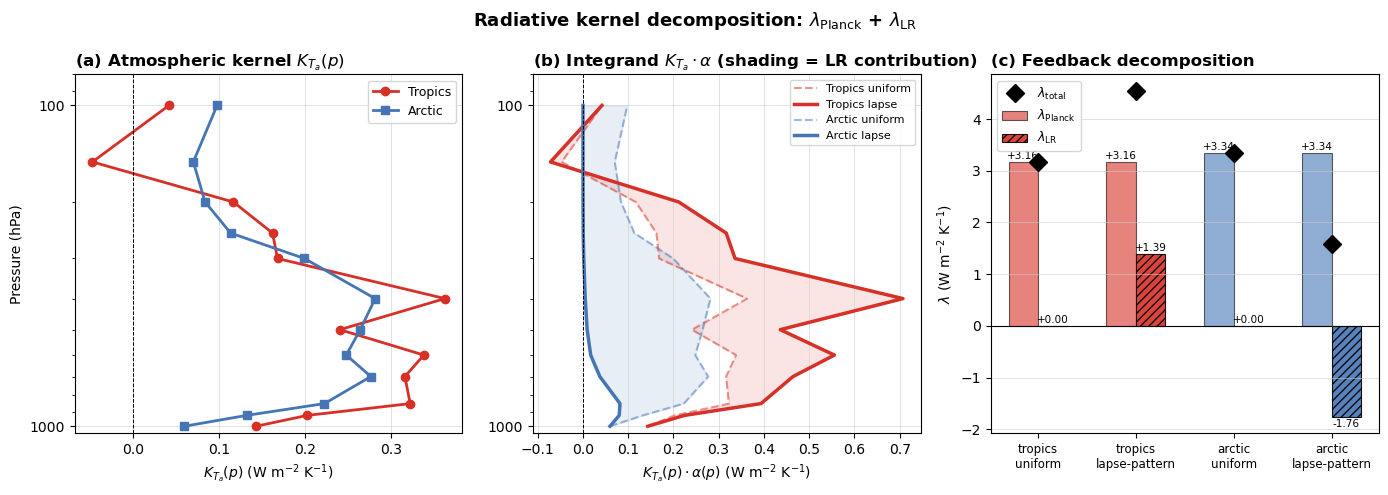

In [37]:
# =============================================================
# Step 3 – visualise the kernel and the feedback decomposition
# =============================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# ---------- (a) K_Ta profiles ----------
ax = axes[0]
p_kern_trp = np.array(sorted(k_ta_trp.keys(), reverse=True))
p_kern_arc = np.array(sorted(k_ta_arc.keys(), reverse=True))
k_vals_trp = np.array([k_ta_trp[p] for p in p_kern_trp])
k_vals_arc = np.array([k_ta_arc[p] for p in p_kern_arc])

ax.plot(k_vals_trp, p_kern_trp, "o-", color=C_TR,  lw=2, ms=6, label="Tropics")
ax.plot(k_vals_arc, p_kern_arc, "s-", color=C_ARC, lw=2, ms=6, label="Arctic")
ax.axvline(0, color="k", lw=0.7, ls="--")
ax.set_yscale("log")
ax.set_ylim(1050, 80)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}"))
ax.set_xlabel(r"$K_{T_a}(p)$ (W m$^{-2}$ K$^{-1}$)", fontsize=10)
ax.set_ylabel("Pressure (hPa)", fontsize=10)
ax.set_title(r"(a) Atmospheric kernel $K_{T_a}(p)$", loc="left", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(which="major", lw=0.4, color="#ccc")
# mark K_Ts values on the right margin
ax.annotate(
    f"$K_{{T_s}}$ = {k_ts_trp:+.3f}", xy=(k_ts_trp, 980),
    xytext=(k_ts_trp + 0.002, 920), fontsize=8, color=C_TR,
    arrowprops=dict(arrowstyle="->", color=C_TR, lw=1),
)
ax.annotate(
    f"$K_{{T_s}}$ = {k_ts_arc:+.3f}", xy=(k_ts_arc, 980),
    xytext=(k_ts_arc - 0.002, 850), fontsize=8, color=C_ARC,
    arrowprops=dict(arrowstyle="->", color=C_ARC, lw=1),
    ha="right",
)

# ---------- (b) kernel × alpha(p): integrand breakdown ----------
ax = axes[1]
p_fine = np.array(KERNEL_LEVELS, dtype=float)

for region_lbl, k_ta, color, alpha_fn_laps in [
    ("Tropics", k_ta_trp, C_TR,  alpha_tropical),
    ("Arctic",  k_ta_arc, C_ARC, alpha_arctic),
]:
    p_k = np.array(sorted(k_ta.keys(), reverse=True))
    k_v = np.array([k_ta[pp] for pp in p_k])
    alpha_v = np.array([alpha_fn_laps(pp) for pp in p_k])

    ax.plot(k_v * 1.0,         p_k, ls="--", lw=1.5, color=color, alpha=0.5,
            label=f"{region_lbl} uniform")
    ax.plot(k_v * alpha_v,     p_k, ls="-",  lw=2.5, color=color,
            label=f"{region_lbl} lapse")
    ax.fill_betweenx(p_k, k_v * 1.0, k_v * alpha_v, alpha=0.12, color=color)

ax.axvline(0, color="k", lw=0.7, ls="--")
ax.set_yscale("log")
ax.set_ylim(1050, 80)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}"))
ax.set_xlabel(r"$K_{T_a}(p)\cdot\alpha(p)$ (W m$^{-2}$ K$^{-1}$)", fontsize=10)
ax.set_title(r"(b) Integrand $K_{T_a}\cdot\alpha$ (shading = LR contribution)", loc="left", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(which="major", lw=0.4, color="#ccc")

# ---------- (c) feedback bar chart ----------
ax = axes[2]
fb = feedback_df.reset_index()
x_labels = [f"{r}\n{w}" for r, w in zip(fb["region"], fb["warming_type"])]
x = np.arange(len(fb))
bw = 0.3

bars_planck = ax.bar(x - bw/2, fb["lambda_Planck"], bw,
                     color=["#d73027" if "trop" in r else "#4575b4" for r in fb["region"]],
                     alpha=0.6, label=r"$\lambda_{\rm Planck}$", edgecolor="k", lw=0.8)
bars_lr = ax.bar(x + bw/2, fb["lambda_LR"], bw,
                 color=["#d73027" if "trop" in r else "#4575b4" for r in fb["region"]],
                 hatch="////", alpha=0.9, label=r"$\lambda_{\rm LR}$", edgecolor="k", lw=0.8)

# total marker
for i, row in fb.iterrows():
    ax.plot(i, row["lambda_total"], "D", ms=9, color="k", zorder=5)
ax.plot([], [], "D", ms=9, color="k", label=r"$\lambda_{\rm total}$")

for bars in (bars_planck, bars_lr):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + (0.02 if h >= 0 else -0.04),
                f"{h:+.2f}", ha="center", va="bottom" if h >= 0 else "top", fontsize=7.5)

ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=8.5)
ax.set_ylabel(r"$\lambda$ (W m$^{-2}$ K$^{-1}$)", fontsize=10)
ax.set_title(r"(c) Feedback decomposition", loc="left", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", lw=0.4, color="#ccc")

plt.suptitle(
    r"Radiative kernel decomposition: $\lambda_{\rm Planck}$ + $\lambda_{\rm LR}$",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()

out_kernel = Path("../../output/lapse_rate_kernel_decomposition.pdf")
out_kernel.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out_kernel, bbox_inches="tight", dpi=150)
print(f"Saved to {out_kernel}")
plt.show()
